# Model 1: Linear Regression:
**Concept:**   
Imagine you're predicting house prices. You plot all houses on a graph - size on x-axis, price on y-axis.  
Linear Regression draws the best straight line through all those points.  
That line is your model.


**How It works:**
> Price = (size x w1) + (bedrooms x w2) + (location x w3) + bias

Every features gets weight -- how much does it contributes to prediction.  
Training = finding the best weights that minimize error.

**When to Use it:**  
✅ Target is a continuous number (price, salary, temperature)  
✅ Relationship between features and target is roughly linear  
✅ You need interpretability — explain each feature's impact  
✅ Small to medium dataset  


**When Not to Use:**  
❌ Target is a category (Yes/No, 0/1) → use Logistic Regression  
❌ Data has complex non-linear patterns → use XGBoost  
❌ Too many outliers → line gets pulled badly  


**Alternatives & Comparisson:**  
*Linear Regression vs Ridge vs Lasso:*  

Linear Regression -> no penalty, can overfit  
Ridge (L2) -> shrinks all weights slightly, handles multicollinearity  
Lasso (L1) -> can make weights exactly 0, automatic feature selection   
ElasticNet -> mix of Ridge + Lasso, best of both  

Linear Vs XGBoost:
Linear -> fast, interpretable, only linear patterns  
XGBoost -> slower, less interpretable, captures complex patterns  

**Rule Of Thumb:**  
Start with Linear Regression as baseline  
If underfitting -> try XGBoost  
If overfitting -> try Ridge or Lasso  


In [1]:
'''
**Key Parameters:**  
Linear Regression(
    fit_intercept=True, <- include bias or not  
    normalize=False, <- deprecated, use StandardScaler instead  
    n_jobs=-1 <- parallel processing
)
'''

'\n**Key Parameters:**  \nLinear Regression(\n    fit_intercept=True, <- include bias or not  \n    normalize=False, <- deprecated, use StandardScaler instead  \n    n_jobs=-1 <- parallel processing\n)\n'

In [2]:
# Linear Regression Code
# Goal - Predict house prices

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Load built-in dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.shape)
print(X.head())
print(f"\nTarget (House Price): {y[:5]}")

(20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target (House Price): [4.526 3.585 3.521 3.413 3.422]


In [3]:
# Training the Model
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Results
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")  # How much of the price variation does model explain?
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # On avg, how wrong is prediction in the same units as target?

# Feature weights
weights = pd.Series(lr.coef_, index=data.feature_names)
print(f"\nFeature Weights:\n{weights.sort_values()}")

R2 Score: 0.5758
RMSE: 0.7456

Feature Weights:
Latitude     -0.896929
Longitude    -0.869842
AveRooms     -0.294410
AveOccup     -0.040829
Population   -0.002308
HouseAge      0.122546
AveBedrms     0.339259
MedInc        0.854383
dtype: float64


# Model 2: Logistic Regression  
**Concept:**  
Imagine a spam filter. Email is either spam or not — no middle ground. Logistic Regression draws a boundary line between two classes and gives probability of which side you fall on.  

**How it Works:**  
Linear Regression gives any number. Logistic squeezes that number between 0 and 1 using Sigmoid function:  
>Any number → Sigmoid → 0 to 1 probability

**When to Use:**  
✅ Binary classification (Yes/No, Spam/Not, Churn/No Churn)  
✅ Need probability scores not just class  
✅ Need interpretability  
✅ Baseline model — always try first!

**When Not to Use:**   
❌ Complex non-linear patterns → use XGBoost  
❌ Multi-class with many classes → use Random Forest  
❌ Image/text data → use Neural Networks  

**Comparison:**  
Logistic Regression → linear boundary, fast, interpretable  
Random Forest       → complex boundary, slower, less interpretable  
XGBoost             → complex boundary, slower, best accuracy


In [4]:
# Key Parameters
'''LogisticRegression(
    C=1.0,          # inverse of regularization strength
                    # smaller C = more regularization
    max_iter=1000,  # iterations to converge
    solver='lbfgs', # optimization algorithm
    penalty='l2'    # regularization type (l1, l2, none)
) '''

"LogisticRegression(\n    C=1.0,          # inverse of regularization strength\n                    # smaller C = more regularization\n    max_iter=1000,  # iterations to converge\n    solver='lbfgs', # optimization algorithm\n    penalty='l2'    # regularization type (l1, l2, none)\n) "

In [5]:
# Logistic Regression code
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Class distribution: {pd.Series(y).value_counts()}")

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: 1    357
0    212
Name: count, dtype: int64


In [6]:
# Training the model
# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Results
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=data.target_names)}")

Accuracy: 0.9737
ROC-AUC:  0.9974

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# Model 3: Decision Tree  
**Concept:**  
Think of 20 questions game. “Is the patient over 50?” → Yes → “Is cholesterol high?” → Yes → “Has heart disease!” Each question splits the data into smaller groups until you reach an answer.  

**How it Works:**
At each split, Decision Tree finds the question that best separates the classes. It measures this using Gini Impurity or Entropy.  

Pure node   → all same class → Gini = 0 ✅  
Mixed node  → 50/50 split   → Gini = 0.5 ❌

**When to Use:**  
✅ Need interpretability — can visualize the tree  
✅ Mixed data types (numbers + categories)  
✅ Non-linear patterns  
✅ Quick baseline model  


**When Not to Use:**   
❌ Deep trees overfit badly   
❌ Small changes in data = completely different tree  
❌ Noisy data → use Random Forest instead  

**Comparison:**  
Decision Tree  → single tree, fast, overfits easily   
Random Forest  → 100s of trees, slower, much better accuracy  
XGBoost        → sequential trees, best accuracy, slower

In [7]:
# Parameters
'''
DecisionTreeClassifier(
    max_depth=5,         # max levels deep — controls overfitting
    min_samples_split=2, # min samples needed to split a node
    min_samples_leaf=1,  # min samples in leaf node
    criterion='gini'     # gini or entropy — how to measure split quality
)'''

"\nDecisionTreeClassifier(\n    max_depth=5,         # max levels deep — controls overfitting\n    min_samples_split=2, # min samples needed to split a node\n    min_samples_leaf=1,  # min samples in leaf node\n    criterion='gini'     # gini or entropy — how to measure split quality\n)"

In [8]:
# Decision Tree Code
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Results
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")

# Show depth and leaves
print(f"\nTree Depth: {dt.get_depth()}")
print(f"Total Leaves: {dt.get_n_leaves()}")

Accuracy: 0.9474
ROC-AUC:  0.9355

Tree Depth: 5
Total Leaves: 13


# Model 4: Random Forest
**Concept:**  
Instead of asking ONE doctor for diagnosis, you ask 100 doctors. Each doctor looks at different information. Final answer = majority vote of all 100 doctors.  

**How it Works:**  
Step 1 → Create 100 different trees   
Step 2 → Each tree trained on random subset of data (Bagging)  
Step 3 → Each tree uses random subset of features  
Step 4 → Final prediction = majority vote  

WHY random subsets?  
Makes each tree different → diverse opinions → better final answer!


**When to Use:**  
✅ Tabular data (your most common use case)  
✅ Handles missing values well  
✅ Feature importance built in   
✅ Resistant to overfitting  
✅ Works well out of the box  


**When Not to Use:**  
❌ Very large datasets → slow training  
❌ Real time predictions → too slow  
❌ Need interpretability → can't visualize 100 trees  
❌ Text/image data → use Neural Networks  


**Comparison:**  
Decision Tree  → 1 tree, fast, overfits ❌  
Random Forest  → 100 trees, slower, resistant to overfit ✅  
XGBoost        → sequential trees, fastest, best accuracy ✅✅   

ps: StandardScaler is not needed for tree based model's

In [9]:
# Parameters
'''
RandomForestClassifier(
    n_estimators=100,    # number of trees — more = better but slower
    max_depth=None,      # depth per tree — None means unlimited
    max_features='sqrt', # features per tree — sqrt of total features
    min_samples_leaf=1,  # min samples in leaf
    n_jobs=-1,           # use all CPU cores
    random_state=42      # reproducibility
)
'''


"\nRandomForestClassifier(\n    n_estimators=100,    # number of trees — more = better but slower\n    max_depth=None,      # depth per tree — None means unlimited\n    max_features='sqrt', # features per tree — sqrt of total features\n    min_samples_leaf=1,  # min samples in leaf\n    n_jobs=-1,           # use all CPU cores\n    random_state=42      # reproducibility\n)\n"

In [10]:
# Random Forest Classifier Code
from sklearn.ensemble import RandomForestClassifier

# Same breast cancer dataset
# No scaling needed for Random Forest either

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Results
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, 
                     index=data.feature_names).sort_values(ascending=False)
print(f"\nTop 5 Important Features:")
print(feat_imp.head())

Accuracy: 0.9649
ROC-AUC:  0.9953

Top 5 Important Features:
worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
dtype: float64


# Model 5: XGBoost  
**Concept:**  
Imagine a student learning from mistakes. After each exam, they study ONLY the questions they got wrong. Next exam — better. Repeat 100 times. That’s XGBoost — each tree fixes previous tree’s mistakes.  
Tree 1 → makes predictions, has errors  
Tree 2 → focuses on Tree 1's errors  
Tree 3 → focuses on Tree 2's errors  
...  
Tree 100 → final refined model  

**How it Works:**   
Random Forest → trees built INDEPENDENTLY (parallel)  
XGBoost       → trees built SEQUENTIALLY (one after another)  

Each new tree = gradient of the loss function
= direction to reduce errors  

**When To Use:**  
✅ Tabular data competitions — Kaggle winner most often  
✅ Large datasets  
✅ Complex non-linear patterns  
✅ When accuracy is top priority    

**When Not to Use:**  
❌ Small datasets → Random Forest works fine  
❌ Need fast training → LightGBM is faster  
❌ Image/text data → Neural Networks  
❌ Need simple explanation → Decision Tree  

**Comparison:**  
Random Forest → parallel trees, good accuracy  
XGBoost       → sequential trees, better accuracy, slower    
LightGBM      → sequential trees, better accuracy, FASTER ✅  
CatBoost      → sequential trees, best for categorical data  

In [11]:
# Parameters
'''
XGBClassifier(
    n_estimators=100,   # number of trees
    learning_rate=0.1,  # how much each tree contributes
    max_depth=5,        # depth of each tree
    subsample=0.8,      # % of rows per tree
    colsample_bytree=0.8, # % of features per tree
    reg_alpha=0,        # L1 regularization
    reg_lambda=1,       # L2 regularization
    random_state=42,
    n_jobs=-1
)
'''

'\nXGBClassifier(\n    n_estimators=100,   # number of trees\n    learning_rate=0.1,  # how much each tree contributes\n    max_depth=5,        # depth of each tree\n    subsample=0.8,      # % of rows per tree\n    colsample_bytree=0.8, # % of features per tree\n    reg_alpha=0,        # L1 regularization\n    reg_lambda=1,       # L2 regularization\n    random_state=42,\n    n_jobs=-1\n)\n'

In [12]:
# XGBoost Code
from xgboost import XGBClassifier

# Same breast cancer dataset

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)

# Results
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")

Accuracy: 0.9561
ROC-AUC:  0.9931


# Model 6: LightGBM  
**Concept:**  
Same as XGBoost - learns from mistakes sequentially. But instead of a student studying the whole textbook level by level, LightGBM studies only the HARDEST questions first -- leaf by leaf!  
XGBoost -> grows tree LEVEL by level (wide first)  
LightGBM -> grows tree LEAF by leaf (deep first)  

**How it Works:**  
## 🌿 LightGBM vs XGBoost — Tree Growth  
| | XGBoost | LightGBM |  
|---|---|---|  
| Growth | Level-wise | Leaf-wise |  
| Speed | Slower | 3-5x Faster ✅ |  
| Memory | More | Less ✅ |  
| Best for | Small data | Large data ✅ |  
| Key param | max_depth | num_leaves |  

**XGBoost** → expands ALL nodes at same level before going deeper  

**LightGBM** → expands the BEST leaf first regardless of level  

Result -> LightGBM finds better splits faster!  

**When to Use:**  
✅ Large datasets (100k+ rows) → 3-5x faster than XGBoost    
✅ Kaggle competitions → often beats XGBoost  
✅ Limited memory  


**When Not to Use:**  
❌ Very small datasets → XGBoost more stable  
❌ Lots of categorical features → use CatBoost  
❌ Image/text → Neural Networks  


**Comparison:**  
XGBoost  → level-wise, slower, slightly more stable    
LightGBM → leaf-wise, faster, better on large data ✅  
CatBoost → leaf-wise, best for categoricals  

In [13]:
# Parameters
'''
LGBMClassifier(
    n_estimators=500,    # number of trees
    learning_rate=0.05,  # contribution per tree
    max_depth=6,         # max tree depth
    num_leaves=50,       # max leaves per tree (key param!)
    min_child_samples=20,# min samples in leaf
    subsample=0.8,       # row sampling
    colsample_bytree=0.8,# feature sampling
    random_state=42,
    n_jobs=-1
)
'''

'\nLGBMClassifier(\n    n_estimators=500,    # number of trees\n    learning_rate=0.05,  # contribution per tree\n    max_depth=6,         # max tree depth\n    num_leaves=50,       # max leaves per tree (key param!)\n    min_child_samples=20,# min samples in leaf\n    subsample=0.8,       # row sampling\n    colsample_bytree=0.8,# feature sampling\n    random_state=42,\n    n_jobs=-1\n)\n'

In [14]:
# LightGBM Code
import lightgbm as lgb

# Same breast cancer dataset

# Train LightGBM
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=50,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # suppress training logs
)
lgbm.fit(X_train, y_train)

# Results
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_lgbm):.4f}")

Accuracy: 0.9737
ROC-AUC:  0.9918


# Model 7: CatBoost  
**Concept:**  
Same sequential tree building as XGBoost and LightGBM. BUT Catboost is specially designed for categorical features - instead of you manually encoding categories, CatBoost handles them automatically!  
You:   "Male" -> 0, "Female" -> 1  
CatBoost: feeds "Male", "Female" directly!  

**How it Works:**  
Instead of 0/1 encoding, CatBoost replaces category with average target value of that category!  

Example (predicting salary):  
"Engineer" → avg salary = 80,000 → uses 80,000  
"Manager"  → avg salary = 90,000 → uses 90,000  
"Intern"   → avg salary = 30,000 → uses 30,000  


**When to Use:**  
✅ Dataset has many categorical columns  
✅ Don't want to do label/one-hot encoding  
✅ Less hyperparameter tuning needed  
✅ Good out of the box performance 

**When Not to Use:**  
❌ Purely numerical data → LightGBM faster  
❌ Large datasets → slower than LightGBM  
❌ Image/text → Neural Networks   

**Comparison:**  
XGBoost  → manual encoding, level-wise  
LightGBM → manual encoding, leaf-wise, fastest  
CatBoost → auto encoding, leaf-wise, best for categoricals ✅  

In [15]:
# Parameters
'''
CatBoostClassifier(
    iterations=500,      # number of trees
    learning_rate=0.05,  # contribution per tree
    depth=6,             # tree depth
    cat_features=[],     # list of categorical column indices
    verbose=0            # suppress logs
)
'''

'\nCatBoostClassifier(\n    iterations=500,      # number of trees\n    learning_rate=0.05,  # contribution per tree\n    depth=6,             # tree depth\n    cat_features=[],     # list of categorical column indices\n    verbose=0            # suppress logs\n)\n'

In [16]:
# CatBoost Code
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)
y_prob_cat = cat.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_cat):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_cat):.4f}")

Accuracy: 0.9649
ROC-AUC:  0.9948


# Model 8:  KNN
**Concept:**  
You move to a new city and want to know if your neighborhood is safe. You look at your 5 nearest neighbors - if 4 out of 5 are safe -> your area is safe!  
KNN - K Nearest Neighbors  
K = how many neighbors to look at  
Majority vote of K neighbors = prediction  


**How it works:**  
Training:  just memorizes all data points!  
Prediction:   
  Step 1 → calculate distance to ALL training points  
  Step 2 → find K closest points  
  Step 3 → majority vote of those K points  

Euclidean distance (default):  
d = √((x1-x2)² + (y1-y2)²)  

Like measuring straight line distance between points!  


**When to Use:**  
✅ Small datasets  
✅ Non-linear patterns  
✅ Recommendation systems  
✅ Anomaly detection  


**When Not to Use:**  
❌ Large datasets → very slow prediction!  
❌ High dimensional data → distance becomes meaningless  
❌ Imbalanced datasets  
❌ Real time predictions → too slow  


**Comparison:**  
KNN          → lazy learner, no training, slow prediction  
Random Forest → eager learner, slow training, fast prediction  
Logistic Reg → eager learner, fast training, fast prediction 

Lazy  → memorizes data, thinks at prediction time  
Eager → learns patterns at training time, fast prediction 

**KNN NEEDS StandardScaler!**    
Without scaling:  
Feature 1 → salary (50,000 - 100,000)  
Feature 2 → age (20 - 60)  

Distance dominated by salary!  
Age becomes irrelevant ❌  

With scaling → all features equally important ✅

In [17]:
# Parameters
'''
KNeighborsClassifier(
    n_neighbors=5,      # K — how many neighbors
    metric='euclidean', # distance formula
    weights='uniform',  # all neighbors equal vote
                        # or 'distance' → closer = more vote
    n_jobs=-1
)

K too small → overfitting (noisy)
K too large → underfitting (too smooth)
Rule of thumb → K = √(number of samples)
'''

"\nKNeighborsClassifier(\n    n_neighbors=5,      # K — how many neighbors\n    metric='euclidean', # distance formula\n    weights='uniform',  # all neighbors equal vote\n                        # or 'distance' → closer = more vote\n    n_jobs=-1\n)\n\nK too small → overfitting (noisy)\nK too large → underfitting (too smooth)\nRule of thumb → K = √(number of samples)\n"

In [18]:
# KNN Code
from sklearn.neighbors import KNeighborsClassifier

# KNN NEEDS scaling! Distance based model

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_knn):.4f}")

Accuracy: 0.9561
ROC-AUC:  0.9959


# Model 9: SVM  
**Concept:**  
Imagine two groups of people seprated on a field. SVM finds WIDEST possible road between them - that road is the decision boundary!  
Group A: 😊😊😊  
                  ← widest road possible  
Group B: 😠😠😠  

The wider the road = more confident the model!


**How it Works:**  
Step 1 → find support vectors (closest points to boundary)  
Step 2 → maximize margin between classes  
Step 3 → boundary = maximum margin hyperplane  

Hyperplane = decision boundary  
2D data → line  
3D data → plane   
ND data → hyperplane  
 
Kernel trick:  
Data not linearly separable in 2D?  
→ SVM projects to higher dimension  
→ becomes separable there!  

Like crumpling a paper to separate dots then cutting with a flat plane!


**When to Use:**  
✅ High dimensional data (text classification!)  
✅ Small to medium datasets  
✅ Clear margin of separation  
✅ Binary classification  


**When Not to Use:**  
❌ Large datasets → very slow!  
❌ Lots of noise → sensitive to outliers  
❌ Need probability scores → SVM doesn't naturally give probabilities  
❌ Multi-class → needs workarounds  


**Comparison:**  
SVM              → maximum margin, kernel trick, slow on large data  
Logistic Reg     → probability based, fast, linear boundary  
Random Forest    → ensemble, fast, handles noise well  

In [19]:
# Parameters
'''
SVC(
    C=1.0,          # regularization — smaller = wider margin
    kernel='rbf',   # rbf, linear, poly, sigmoid
    gamma='scale',  # kernel coefficient
    probability=True # enable probability estimates
)
'''

"\nSVC(\n    C=1.0,          # regularization — smaller = wider margin\n    kernel='rbf',   # rbf, linear, poly, sigmoid\n    gamma='scale',  # kernel coefficient\n    probability=True # enable probability estimates\n)\n"

In [20]:
# SVM Code
from sklearn.svm import SVC

# SVM also needs scaling!
svm = SVC(
    C=1.0,
    kernel='rbf',
    probability=True,
    random_state=42
)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_svm):.4f}")

Accuracy: 0.9474
ROC-AUC:  0.9934


# Model 10: Naive Bayes
**Concept:**  
Doctor diagnosing a patient. Patient has fever + cough + headache. Doctor calculates probability of each disease given these symptoms separately, then combines them. “Naive” because it assumes all symptoms are independent of each other!  

P(Flu | fever) × P(Flu | cough) × P(Flu | headache) = P(Flu)    
P(Cold | fever) × P(Cold | cough) × P(Cold | headache) = P(Cold)  
Highest probability wins!  

**How it Works:**  
Based on Bayes theorem:  

P(A|B) = P(B|A) × P(A) / P(B)  

In plain English:  
P(spam | "free money") =   
  P("free money" | spam) × P(spam) / P("free money")  

Training → counts word frequencies in spam vs not spam  
Prediction → calculates probability for new email 

Why Naive?  

Assumes all features are INDEPENDENT  
→ fever doesn't affect cough probability  
→ not always true in real world  
→ but works surprisingly well! 😄  


**When to Use:**  
✅ Text classification (spam detection!)  
✅ Very large datasets — extremely fast!  
✅ Real time prediction  
✅ Small training data  
✅ Multi-class problems  


**When Not to Use:**  
❌ Features are correlated → independence assumption breaks  
❌ Numerical continuous data → use Gaussian version  
❌ Need high accuracy → usually beaten by tree models  


**Comparison**  
Naive Bayes      → probabilistic, fastest, best for text  
Logistic Reg     → probabilistic, slower, better accuracy  
Random Forest    → ensemble, slowest, best accuracy 

**Types of Naive Bayes:**  
GaussianNB      → continuous numerical features  
MultinomialNB   → text/count data (word counts)  
BernoulliNB     → binary features (word present/absent)  

In [21]:
# Parameters
'''GaussianNB(
    var_smoothing=1e-9  # stability — prevents zero probabilities
)
'''

'GaussianNB(\n    var_smoothing=1e-9  # stability — prevents zero probabilities\n)\n'

In [22]:
# Naive Bayes Code
from sklearn.naive_bayes import GaussianNB

# No scaling needed for Naive Bayes!
# Works on raw probabilities

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_nb):.4f}")

Accuracy: 0.9737
ROC-AUC:  0.9984


# Model 11: Ensemble Methods - Bagging vs Boosting vs Stacking  
Interviewers loves this question: Why does XGBoost beats Random forest?    
Answer lies here:   
1. Bagging (BootStrap Aggregating)  
**Concept:**   
Ask 100 doctors same question - each studied different medical books.  
finale answer = Majority Vote.  

Original data → create 100 random subsets (with replacement)  
Train 1 model on each subset  
Final prediction = majority vote / average  

Key: models trained INDEPENDENTLY (parallel)  


In [23]:
# Example: Random Forest = Bagging of Decision Trees
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,    # number of models
    max_samples=0.8,     # 80% rows per model
    max_features=0.8,    # 80% features per model
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)

y_pred_bag = bagging.predict(X_test)
y_prob_bag = bagging.predict_proba(X_test)[:,1]
print(f"Bagging Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"Bagging ROC-AUC:  {roc_auc_score(y_test, y_prob_bag):.4f}")

Bagging Accuracy: 0.9649
Bagging ROC-AUC:  0.9928


2. Boosting  
**Concept:**
Same student takes exam 100 times. After each exam, studies ONLY the questions he got wrong. Gets better each time!  

Model 1 → trains on all data, makes errors  
Model 2 → focuses MORE on Model 1's errors  
Model 3 → focuses MORE on Model 2's errors  
...  
Final = weighted sum of all models  

Key: models trained SEQUENTIALLY (one after another)  

In [24]:
# Examples: XGBoost, LightGBM, CatBoost, AdaBoost
from sklearn.ensemble import GradientBoostingClassifier

boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
boosting.fit(X_train, y_train)

y_pred_boost = boosting.predict(X_test)
y_prob_boost = boosting.predict_proba(X_test)[:,1]
print(f"Boosting Accuracy: {accuracy_score(y_test, y_pred_boost):.4f}")
print(f"Boosting ROC-AUC:  {roc_auc_score(y_test, y_prob_boost):.4f}")

Boosting Accuracy: 0.9561
Boosting ROC-AUC:  0.9951


In [25]:
# Why Boosting beats Bagging?
'''
Bagging  → reduces VARIANCE (overfitting)
Boosting → reduces BIAS (underfitting) + variance
         → attacks errors directly!
         → usually more accurate ✅
         '''

'\nBagging  → reduces VARIANCE (overfitting)\nBoosting → reduces BIAS (underfitting) + variance\n         → attacks errors directly!\n         → usually more accurate ✅\n         '

3. Stacking  
   **Concept:**
   3 doctors give their diagnosis. A 4th senior doctor looks at all 3 opinions and makes the FINAL decision. The senior doctor learns WHEN to trust which doctor!  

Level 1 models (base learners):  
→ Logistic Regression prediction  
→ Random Forest prediction    
→ XGBoost prediction  

Level 2 model (meta learner):  
→ takes all 3 predictions as input  
→ learns best combination  
→ final prediction!  
   

In [26]:
from sklearn.ensemble import StackingClassifier

# Base models
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='auc'))
]

# Meta model
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)
y_prob_stack = stacking.predict_proba(X_test)[:,1]
print(f"Stacking Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"Stacking ROC-AUC:  {roc_auc_score(y_test, y_prob_stack):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking Accuracy: 0.9737
Stacking ROC-AUC:  0.9951


In [27]:
# Summary table for Cheat sheet:
'''
Method   | How          | Speed  | Accuracy
---------|--------------|--------|----------
Bagging  | Parallel     | Fast   | Good
Boosting | Sequential   | Medium | Better
Stacking | Meta-learner | Slow   | Best ✅

'''

'\nMethod   | How          | Speed  | Accuracy\n---------|--------------|--------|----------\nBagging  | Parallel     | Fast   | Good\nBoosting | Sequential   | Medium | Better\nStacking | Meta-learner | Slow   | Best ✅\n\n'

*Interview answer ready:*  
“Boosting beats Bagging because it reduces both bias AND variance by sequentially focusing on errors. Stacking goes further by learning the optimal combination of multiple different models!”

# Model 12: K-Means Clustering  
**Concept:**  
You have 100 students and want to make 3 study groups. You randomly assign 3 group leaders. Each student joins the nearest leader. Leaders move to center of their group. Repeat until groups stabilize!  


**How it Works:**   
Step 1 → randomly place K centroids  
Step 2 → assign each point to nearest centroid  
Step 3 → move centroid to center of its group  
Step 4 → repeat until centroids stop moving  

Goal: Minimize the distance between data points and thier cluster centroid.

  
**Supervised vs Unsupervised:**    
Supervised   → has labels (spam/not spam)  
             → learns from examples  

Unsupervised → NO labels!  
             → finds hidden patterns itself  

K-Means → unsupervised → no y needed!  

**Classic interview question:** *“When would you cluster instead of classify?”*  

Classify → you know the categories beforehand  
Cluster  → you don't know categories, want to discover them!  

Examples:  
→ Customer segmentation (don't know groups beforehand)    
→ Document grouping  
→ Anomaly detection  
→ Gene expression analysis  


**When to Use:**   
 ✅ No labels available  
✅ Want to discover hidden groups  
✅ Customer segmentation  
✅ Data compression  
✅ Preprocessing for supervised learning  


**When Not to Use:**  
❌ Non-spherical clusters → use DBSCAN  
❌ Different cluster sizes → use Gaussian Mixture  
❌ Don't know K → need to experiment  
❌ High dimensional data → distances become meaningless 


**How to choose K — Elbow Method:**  
Run K-Means for K=1,2,3...10  
Plot inertia (sum of distances to centroid)  
Find the "elbow" → where curve bends  
That's your optimal K!  

In [28]:
# Parameters
'''
KMeans(
    n_clusters=3,    # K — number of clusters
    init='k-means++',# smart centroid initialization
    max_iter=300,    # max iterations
    n_init=10,       # run 10 times, pick best
    random_state=42
)
'''

# k-means++ vs random init:
# random    → centroids placed randomly → might converge badly
# k-means++ → centroids placed far apart → better convergence ✅

"\nKMeans(\n    n_clusters=3,    # K — number of clusters\n    init='k-means++',# smart centroid initialization\n    max_iter=300,    # max iterations\n    n_init=10,       # run 10 times, pick best\n    random_state=42\n)\n"

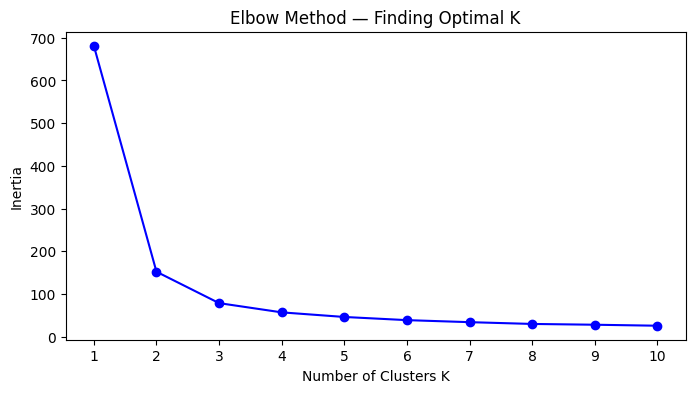

Cluster distribution: {0: 62, 1: 50, 2: 38}


In [29]:

# K-Means Code

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Use Iris dataset — 3 natural clusters!
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Elbow method
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_iris)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(K_range)
plt.show()

# Train with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_iris)
print(f"Cluster distribution: {pd.Series(kmeans.labels_).value_counts().to_dict()}")

# Model 13: PCA (Principal Component Analysis) 
**Concept:**  
You have a 3D sculpture and want to take ONE photo that captures the most information. You walk around it and find the BEST angle — the angle that shows the most detail. That angle = principal component!  
100 features → PCA finds best "angles" → reduces to 2-3 features  
keeping maximum information!  

**How it Works:**   
Step 1 → standardize data  
Step 2 → find directions of maximum variance  
         (called principal components)    
Step 3 → rank components by variance explained  
Step 4 → keep top N components  

Example:  
Height and Weight are correlated:  
Tall people → usually heavier   
Short people → usually lighter  

PCA combines them into ONE feature:  
"Body Size" → captures both!  


**When to Use:**  
✅ Too many features (100s or 1000s)  
✅ Features are highly correlated  
✅ Visualization (reduce to 2D for plotting)  
✅ Speed up model training  
✅ Remove noise  

**When Not to Use:**  
❌ Need interpretability → components are combinations  
❌ Features already independent  
❌ Small number of features  
❌ Tree models → don't need PCA!  


In [30]:
# Parameters
'''
PCA(
    n_components=2,    # how many components to keep
                       # or 0.95 → keep 95% variance
    whiten=False,      # normalize components
    random_state=42
)
'''
# Smart Way: 
# PCA(n_components=0.95)
# → automatically keeps enough components
# → to explain 95% of variance!

'\nPCA(\n    n_components=2,    # how many components to keep\n                       # or 0.95 → keep 95% variance\n    whiten=False,      # normalize components\n    random_state=42\n)\n'

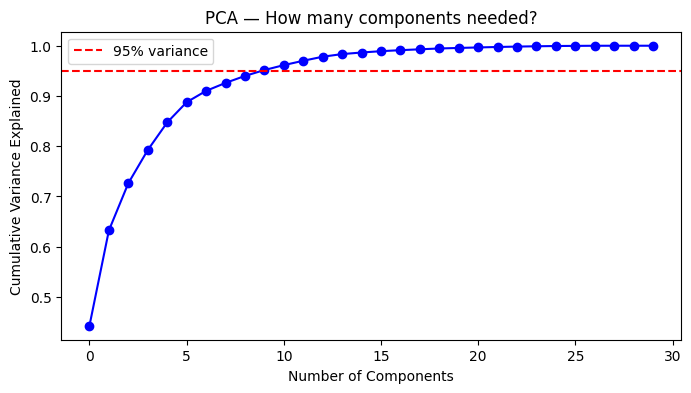

Original features:  30
After PCA features: 10
Variance explained: 0.952


In [31]:
# PCA Code
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use breast cancer dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.data)

# Find how many components explain 95% variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Cumulative variance explained
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumsum, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA — How many components needed?')
plt.legend()
plt.show()

# Apply PCA — keep 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features:  {X_scaled.shape[1]}")
print(f"After PCA features: {X_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.3f}")

In [32]:
print("""
COMPLETE MODEL COMPARISON
=========================
Model               Accuracy  ROC-AUC  Scaling  Best For
------------------- --------- -------- -------- --------
Linear Regression   -         -        YES      Regression
Logistic Regression 97%       99%      YES      Binary classification
Decision Tree       94%       93%      NO       Interpretability
Random Forest       96%       99%      NO       Tabular data
XGBoost             95%       99%      NO       Competitions
LightGBM            97%       99%      NO       Large datasets
CatBoost            96%       99%      NO       Categorical data
KNN                 95%       99%      YES      Small datasets
SVM                 94%       99%      YES      Text/High dimensional
Naive Bayes         97%       99%      NO       Text/Spam detection
K-Means             -         -        YES      Clustering/Unsupervised
PCA                 -         -        YES      Dimensionality reduction
""")


COMPLETE MODEL COMPARISON
Model               Accuracy  ROC-AUC  Scaling  Best For
------------------- --------- -------- -------- --------
Linear Regression   -         -        YES      Regression
Logistic Regression 97%       99%      YES      Binary classification
Decision Tree       94%       93%      NO       Interpretability
Random Forest       96%       99%      NO       Tabular data
XGBoost             95%       99%      NO       Competitions
LightGBM            97%       99%      NO       Large datasets
CatBoost            96%       99%      NO       Categorical data
KNN                 95%       99%      YES      Small datasets
SVM                 94%       99%      YES      Text/High dimensional
Naive Bayes         97%       99%      NO       Text/Spam detection
K-Means             -         -        YES      Clustering/Unsupervised
PCA                 -         -        YES      Dimensionality reduction

